# 07 · Avaliação final na base de teste

Até aqui, toda escolha foi feita olhando treino e validação: faixas do WoE, variáveis, hiperparâmetros, modelo e ponto de corte. A base de teste (15% dos dados, separada no notebook 02) não foi usada em nenhum momento.

Agora ela é usada **uma única vez**, com tudo congelado. Os modelos são os já treinados, e o cutoff é o escolhido na validação, sem reotimizar. Se os números do teste ficarem próximos dos da validação, as escolhas não foram sobreajustadas à validação, e esses são os números que vão para o README.

In [1]:
import json
import warnings

warnings.filterwarnings("ignore", module="shap")
warnings.filterwarnings("ignore", message="IProgress not found")

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import brier_score_loss

from credit_scoring.cutoff import ProfitAssumptions, optimal, profit_curve, simulate
from credit_scoring.data import PROCESSED_DIR, ROOT, TARGET
from credit_scoring.explain import GROUP_LABELS, lgbm_reason_codes
from credit_scoring.features import FEATURES
from credit_scoring.metrics import band_table, calibration_table, evaluate
from credit_scoring.plotting import BLUE, GRAY, ORANGE, savefig, set_style
from credit_scoring.reporting import METRICS_PATH, brl, update_metrics
from credit_scoring.scorecard import SCORECARD_FEATURES, proba_to_score

set_style()
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

metrics = json.loads(METRICS_PATH.read_text())
cutoff = metrics["cutoff"]["optimal_cutoff"]
a = metrics["cutoff"]["assumptions"]
assumptions = ProfitAssumptions(ticket=a["ticket"], margin_rate=a["margin_rate"], ead_rate=a["ead_rate"], lgd=a["lgd"])

test = pd.read_parquet(PROCESSED_DIR / "test.parquet")
y_test = test[TARGET].values
booster = lgb.Booster(model_file=str(ROOT / "models" / "lightgbm.txt"))
logistic = joblib.load(ROOT / "models" / "logistic_woe.joblib")
p_gbm = booster.predict(test[FEATURES])
p_sc = logistic.predict_proba(test[SCORECARD_FEATURES])[:, 1]
print(f"{len(test):,} propostas no teste · cutoff congelado da validação: {cutoff}")

22,500 propostas no teste · cutoff congelado da validação: 0.24


## 1. Desempenho: teste vs validação

In [2]:
val = pd.read_parquet(PROCESSED_DIR / "val.parquet")
preds = {
    "scorecard": {"validação": (val[TARGET], logistic.predict_proba(val[SCORECARD_FEATURES])[:, 1]), "teste": (y_test, p_sc)},
    "LightGBM": {"validação": (val[TARGET], booster.predict(val[FEATURES])), "teste": (y_test, p_gbm)},
}
perf = pd.DataFrame({
    (model, split): {**evaluate(y, p), "brier": brier_score_loss(y, p)}
    for model, splits in preds.items() for split, (y, p) in splits.items()
}).T
perf

auc   gini     ks  brier
scorecard validação 0.8614 0.7227 0.5649 0.0503
          teste     0.8618 0.7237 0.5693 0.0498
LightGBM  validação 0.8707 0.7415 0.5898 0.0487
          teste     0.8715 0.7430 0.5851 0.0484

Os números do teste ficam muito próximos dos da validação para os dois modelos, e a vantagem do LightGBM sobre o scorecard se mantém. Não há sinal de que as escolhas feitas olhando a validação tenham se ajustado demais a ela.

## 2. Calibração no teste

A simulação financeira depende das probabilidades, então vale confirmar que elas continuam fiéis à realidade fora da amostra usada para escolher o cutoff.

In [3]:
cal = calibration_table(y_test, p_gbm)
display(cal)

bands = band_table(y_test, proba_to_score(p_gbm), n_bands=10)
print(f"as 10% propostas de menor score concentram {bands['%_maus_acumulado'].iloc[0]:.0%} dos inadimplentes do teste")

,prevista,observada,n
faixa,,,
1,0.0048,0.0040,2250
2,0.0070,0.0027,2250
3,0.0093,0.0098,2250
4,0.0127,0.0111,2250
5,0.0182,0.0178,2250
6,0.0273,0.0218,2250
7,0.0415,0.0422,2250
8,0.0649,0.0636,2250
9,0.1154,0.1209,2250


as 10% propostas de menor score concentram 56% dos inadimplentes do teste


Prevista e observada continuam próximas. O maior desvio relativo está nas faixas de risco muito baixo, onde há só algumas dezenas de inadimplentes por faixa e qualquer diferença pequena pesa muito em termos relativos. A concentração de inadimplentes nas faixas de score mais baixo também se repete.

## 3. O resultado financeiro no teste

Aqui está a conta que importa: a política com o cutoff escolhido na validação, aplicada a propostas que o processo nunca viu, comparada ao cutoff padrão de 0,50 e a aprovar todo mundo.

In [4]:
policies = {
    "aprovar todos": simulate(y_test, p_gbm, 1.0, assumptions),
    "cutoff 0,50 (padrão)": simulate(y_test, p_gbm, 0.5, assumptions),
    f"cutoff {cutoff} · scorecard": simulate(y_test, p_sc, metrics["cutoff"]["policies"]["optimal_scorecard"]["cutoff"], assumptions),
    f"cutoff {cutoff} · LightGBM": simulate(y_test, p_gbm, cutoff, assumptions),
}
table = pd.DataFrame(policies).T[["cutoff", "aprovação", "inadimplência_carteira", "maus_aprovados", "bons_recusados", "margem", "perdas", "lucro"]]
table.index = [i.replace(f"cutoff {cutoff} · scorecard", "cutoff da validação · scorecard") for i in table.index]
table.style.format({"cutoff": "{:.3f}", "aprovação": "{:.1%}", "inadimplência_carteira": "{:.2%}",
                    "maus_aprovados": "{:,.0f}", "bons_recusados": "{:,.0f}", "margem": brl, "perdas": brl, "lucro": brl})

,cutoff,aprovação,inadimplência_carteira,maus_aprovados,bons_recusados,margem,perdas,lucro
aprovar todos,1.000,100.0%,6.68%,"1,504",0,R$ 31.494.000,R$ 7.219.200,R$ 24.274.800
"cutoff 0,50 (padrão)",0.500,97.8%,5.46%,"1,202",191,R$ 31.207.500,R$ 5.769.600,R$ 25.437.900
cutoff da validação · scorecard,0.190,92.7%,3.92%,818,959,R$ 30.055.500,R$ 3.926.400,R$ 26.129.100
cutoff 0.24 · LightGBM,0.240,92.5%,3.80%,792,969,R$ 30.040.500,R$ 3.801.600,R$ 26.238.900


In [5]:
naive, chosen = policies["cutoff 0,50 (padrão)"], policies[f"cutoff {cutoff} · LightGBM"]
losses_avoided = naive["perdas"] - chosen["perdas"]
margin_lost = naive["margem"] - chosen["margem"]
profit_gain = chosen["lucro"] - naive["lucro"]
per_10k = 10_000 / len(test)

test_best = optimal(profit_curve(y_test, p_gbm, assumptions))
print(f"Trocando o cutoff de 0,50 para {cutoff}, no teste:")
print(f"  perdas evitadas:  {brl(losses_avoided)}  ({losses_avoided / naive['perdas']:.0%} das perdas)")
print(f"  margem abdicada:  {brl(margin_lost)}  ({margin_lost / naive['margem']:.1%} da margem)")
print(f"  ganho líquido:    {brl(profit_gain)}  (+{profit_gain / naive['lucro']:.1%} de lucro)")
print(f"  a cada 10 mil propostas: {brl(profit_gain * per_10k)}")
print(f"\nSó para referência: o cutoff ótimo *no teste* seria {test_best['cutoff']}, com lucro de {brl(test_best['lucro'])} "
      f"({(test_best['lucro'] / chosen['lucro'] - 1):+.2%} em relação ao cutoff congelado).")

Trocando o cutoff de 0,50 para 0.24, no teste:
  perdas evitadas:  R$ 1.968.000  (34% das perdas)
  margem abdicada:  R$ 1.167.000  (3.7% da margem)
  ganho líquido:    R$ 801.000  (+3.1% de lucro)
  a cada 10 mil propostas: R$ 356.000

Só para referência: o cutoff ótimo *no teste* seria 0.2, com lucro de R$ 26.253.600 (+0.06% em relação ao cutoff congelado).


O resultado da validação se confirma. Com o cutoff escolhido lá, a carteira do teste evita uma fatia grande das perdas abrindo mão de uma parte pequena da margem, e o lucro fica praticamente igual ao que se teria com o cutoff "perfeito" calculado no próprio teste. A escolha do cutoff generaliza.

O gráfico abaixo resume a troca: perdas e margem com o cutoff padrão e com o cutoff escolhido.

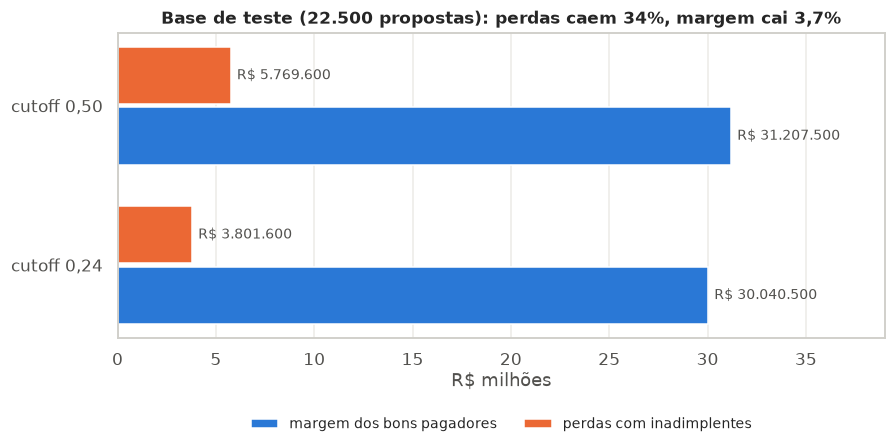

In [6]:
fig, ax = plt.subplots(figsize=(9, 3.6))
labels = ["cutoff 0,50", f"cutoff {cutoff}".replace(".", ",")]
y = np.arange(2)
ax.barh(y + 0.19, [naive["margem"] / 1e6, chosen["margem"] / 1e6], height=0.36, color=BLUE, label="margem dos bons pagadores")
ax.barh(y - 0.19, [naive["perdas"] / 1e6, chosen["perdas"] / 1e6], height=0.36, color=ORANGE, label="perdas com inadimplentes")
for yi, (m, l) in zip(y, [(naive["margem"], naive["perdas"]), (chosen["margem"], chosen["perdas"])]):
    ax.text(m / 1e6 + 0.3, yi + 0.19, brl(m), va="center", fontsize=9, color=GRAY)
    ax.text(l / 1e6 + 0.3, yi - 0.19, brl(l), va="center", fontsize=9, color=GRAY)
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel("R$ milhões", labelpad=2)
ax.set_xlim(0, naive["margem"] / 1e6 * 1.25)
n_fmt = f"{len(test):,}".replace(",", ".")
margin_pct = f"{margin_lost / naive['margem']:.1%}".replace(".", ",")
ax.set_title(f"Base de teste ({n_fmt} propostas): perdas caem {losses_avoided / naive['perdas']:.0%}, margem cai {margin_pct}",
             fontsize=11)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=2, frameon=False, fontsize=9)
ax.grid(axis="y", visible=False)
savefig(fig, "test_losses_vs_margin")
plt.show()

## 4. Motivos de recusa no teste

In [7]:
refused = test[p_gbm > cutoff]
reasons = lgbm_reason_codes(booster, refused)
top1 = reasons["motivo_1"].value_counts(normalize=True)
top1.to_frame("% das recusas como motivo principal").style.format("{:.1%}")

,% das recusas como motivo principal
motivo_1,
Histórico de atrasos,88.0%
Uso do crédito rotativo,11.5%
Linhas de crédito e financiamentos,0.2%
Comprometimento com dívidas,0.2%


A distribuição dos motivos é parecida com a da validação: histórico de atrasos na frente, seguido pelo uso do rotativo.

## 5. Salvando os números finais

Estes são os números que o README cita.

In [8]:
update_metrics("test", {
    "n_rows": int(len(test)),
    "cutoff": cutoff,
    "logistic": {k: round(v, 4) for k, v in evaluate(y_test, p_sc).items()},
    "lightgbm": {k: round(v, 4) for k, v in evaluate(y_test, p_gbm).items()},
    "lightgbm_brier": round(float(brier_score_loss(y_test, p_gbm)), 5),
    "bad_share_lowest_decile": round(float(bands["%_maus_acumulado"].iloc[0]), 4),
    "policies": {
        "approve_all": {k: round(float(v), 4) for k, v in policies["aprovar todos"].items()},
        "cutoff_050": {k: round(float(v), 4) for k, v in naive.items()},
        "chosen": {k: round(float(v), 4) for k, v in chosen.items()},
    },
    "losses_avoided_vs_050": round(float(losses_avoided), 2),
    "losses_avoided_pct": round(float(losses_avoided / naive["perdas"]), 4),
    "margin_lost_vs_050": round(float(margin_lost), 2),
    "margin_lost_pct": round(float(margin_lost / naive["margem"]), 4),
    "profit_gain_vs_050": round(float(profit_gain), 2),
    "profit_gain_pct": round(float(profit_gain / naive["lucro"]), 4),
    "profit_gain_vs_050_per_10k": round(float(profit_gain * per_10k), 2),
    "test_optimal_cutoff_reference": float(test_best["cutoff"]),
    "n_refused": int(len(reasons)),
    "top1_reason_share": {k: round(float(v), 4) for k, v in top1.items()},
})["test"]["losses_avoided_pct"]

0.3411